In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import sklearn
from sklearn.metrics import roc_auc_score, f1_score
from custom_transformers import IQRClipper, PdaysFeatures

In [2]:
train_df = pd.read_parquet('train_processed.parquet')
val_df = pd.read_parquet('val_processed.parquet')
test_df = pd.read_parquet('test_processed.parquet')

X_test = test_df.drop(columns='target')
y_test = test_df['target']

X_train = train_df.drop(columns='target')
X_val = val_df.drop(columns='target')
y_val = val_df['target']

In [4]:
model = joblib.load('BankMarket_model_XGB.joblib')

y_test_proba = model.predict_proba(X_test)[:, 1]
y_test_preds = model.predict(X_test)

test_score = roc_auc_score(y_test, y_test_proba)
test_f1 = f1_score(y_test, y_test_preds, average='weighted')
print(f'Фінальні підсумкові метрики на тестових даних:\nROC-AUC  {test_score:.4f}\nF1 score  {test_f1:.4f}')

Фінальні підсумкові метрики на тестових даних:
ROC-AUC  0.8233
F1 score  0.8823


<Axes: xlabel='Feature'>

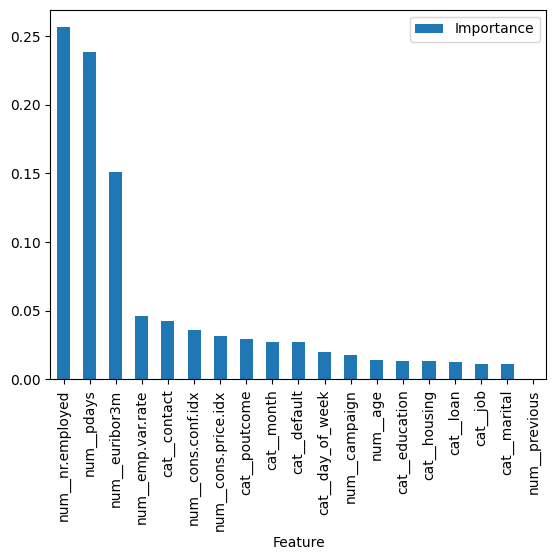

In [6]:
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

feature_importance_df.set_index('Feature').plot.bar()

Судячи з графіку оцінки впливу ознак на цільову зміну, ознаки `nr.employed`, `pdays` та `euribor3m` є найвпливовішими. На мій погляд високий вплив цих ознак має сенс, оскільки макроекономічні показники "величини відсоткової ставки" та "загальний стан економіки регіону" а також як давно контакт центр звязувався з клієнтом в межех кампанії можуть сильно впливати на рішення людини чи погоджуватися на строковий депозит у банку.

## Аналіз результатів за допомогою SHAP

In [8]:
# обʼєкт для пояснення прогнозів моделі за допомогою SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

# візуалізація
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_train.iloc[0,:])

За верхнім графіком видно, що `contact` та `day_of_week` в загальному підвищує прогноз, а наприклад `default`, `education` та `age` знижують прогноз. Базове значення = -2.149

In [9]:
sample_size = 500
subset_indices = np.random.choice(X_train.shape[0], sample_size, replace=False)

# Створюємо підмножину SHAP значень
shap_values_subset = shap_values[subset_indices]
X_train_subset = X_train.iloc[subset_indices]

# Візуалізація для підмножини
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values_subset, X_train_subset)

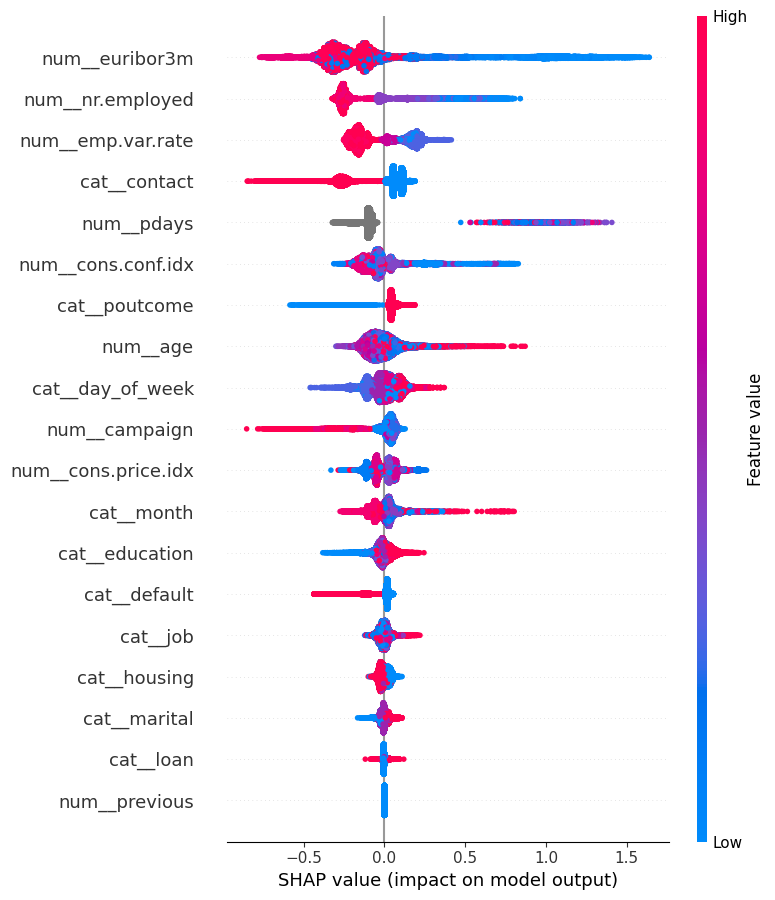

In [10]:
shap_values = shap.TreeExplainer(model).shap_values(X_train)
shap.summary_plot(shap_values, X_train)

На основі графіку можна зробити висновок, що:
*   Ознаки `nr.employed`, `euribor3m`, `emp.var.rate`, `contact`, `campaign` сильно негативно корелюють з цільовою ознакою  
*   Ознаки `day_of_week`, `age`, `month`, `education`, `poutcome`, `cons.conf.idx` мають сильну позитивну кореляцію з цільовою ознакою


In [11]:
# бінарні прогнози за обраним порогом (наприклад, 0.5)
y_pred = (model.predict_proba(X_val)[:, 1] >= 0.5).astype(int)

# індекси помилкових передбачень
fp_indices = np.where((y_val == 0) & (y_pred == 1))[0]
fn_indices = np.where((y_val == 1) & (y_pred == 0))[0]

# SHAP-значення для валідаційної вибірки
explainer = shap.TreeExplainer(model)

In [12]:
explainer = shap.TreeExplainer(model)

shap_explanation = explainer(X_val)

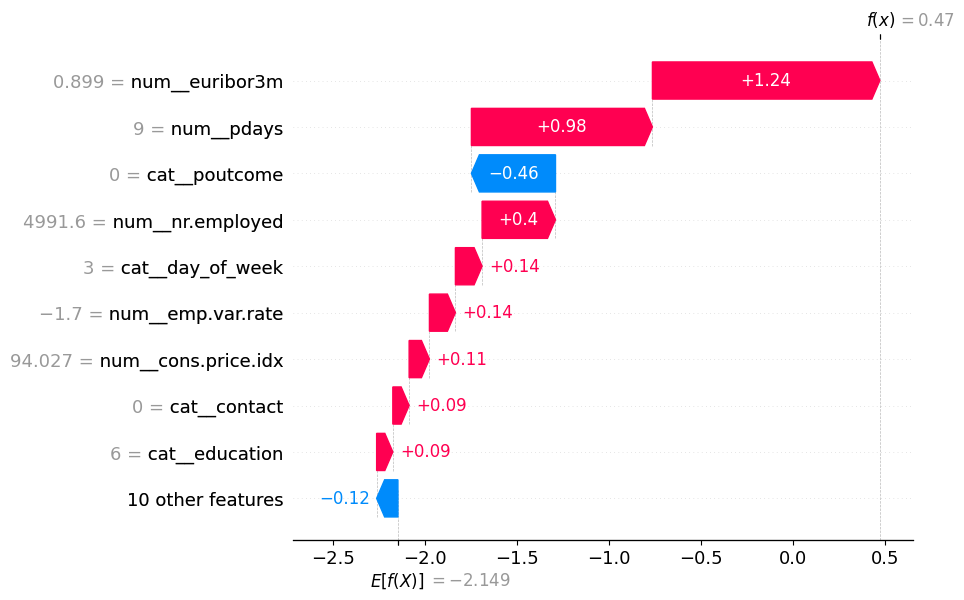

In [13]:
idx_fp = fp_indices[0]
shap.plots.waterfall(shap_explanation[idx_fp])

За графіком видно, що ознаки, які направили модель до хибно позитивного прогнозу: `euribor3m`, `pdays`. Можна також виділити `nr.employed`.

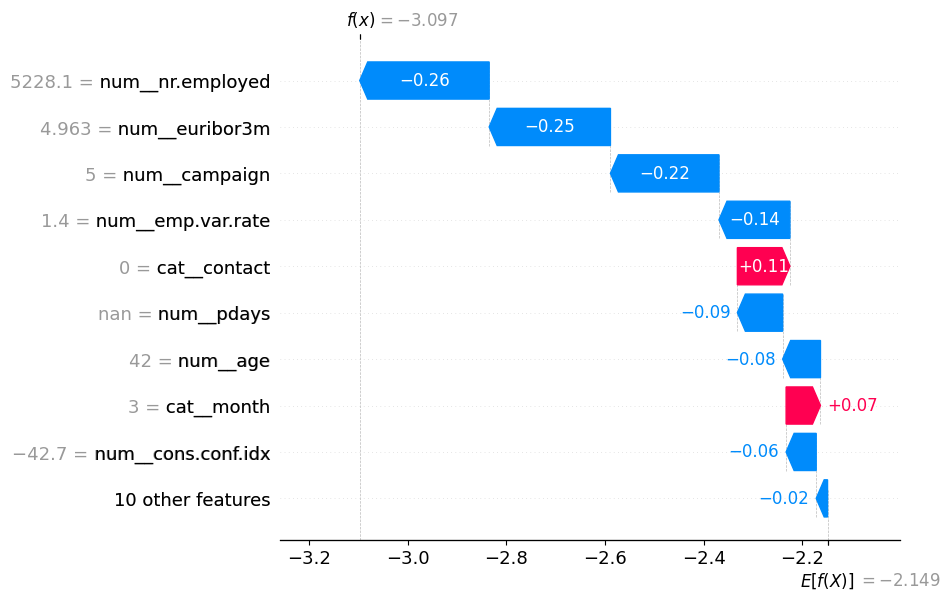

In [14]:
idx_fn = fn_indices[0]
shap.plots.waterfall(shap_explanation[idx_fn])

За графіком видно, що ознаки, які направили модель до хибно негативного прогнозу: `euribor3m`, `nr.employed`, `campaign`. Можна також виділити `emp.var.rate`.

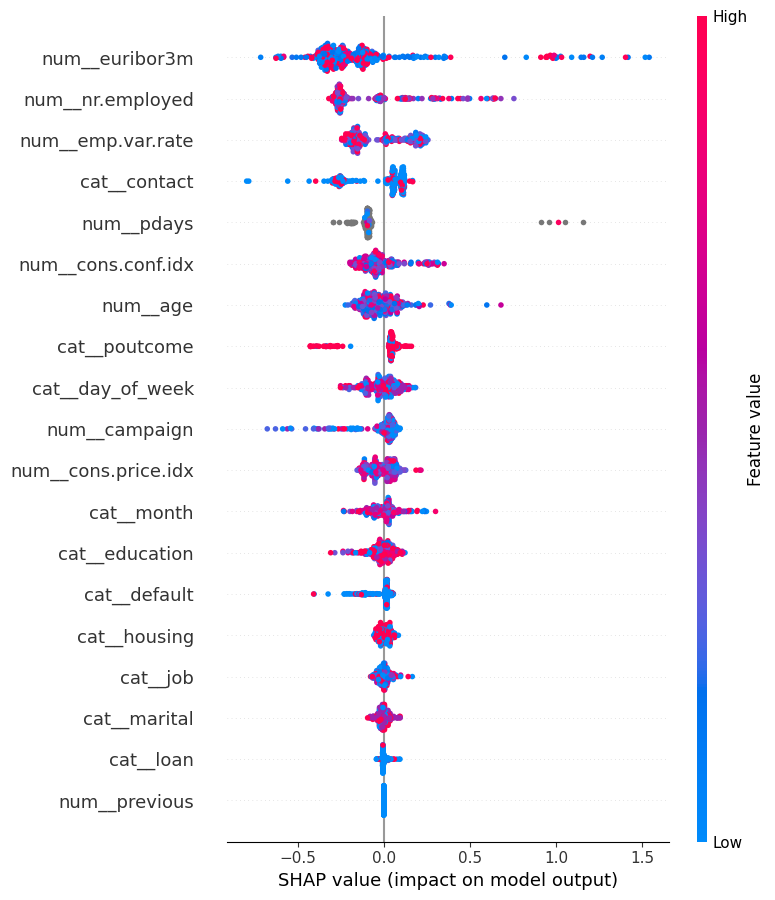

In [16]:
shap.summary_plot(shap_values[fn_indices], X_val.iloc[fn_indices])

### Шляхи та гіпотези для покращення моделі

* **Альтернативна обробка та трансформація ознак:**
  * Ознаки `euribor3m` та `pdays` критично сильно викривляють прогнози моделі.
  * *Рішення:* Змінити стратегію їхнього препроцесингу (наприклад, застосувати робастне обмеження викидів, логарифмування або створення спеціальних категоріальних прапорців для нетипових значень).

* **Створення комбінованої макроекономічної ознаки (Feature Engineering):**
  * Макроекономічні показники мають високу важливість у моделі, але одночасно створюють значну частку помилок передбачення.
  * *Рішення:* Згенерувати агреговану або зважену ознаку на основі сукупності макроекономічних індикаторів, щоб згладити шум і виділити загальний економічний тренд.

* **Зміна стратегії кодування (Categorical Encoding):**
  * Застосувати `OneHotEncoder` замість `OrdinalEncoder` / `LabelEncoder` для неансамблевих (класичних) моделей.
  * *Рішення:* Провести повторний порівняльний аналіз метрик після перекодування — це може виявити точнішу класичну модель.